In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from collections import Counter
import random
from matplotlib.colors import ListedColormap, BoundaryNorm

### The dataset contains 3D CT scans of wooden logs represented in 2D slices. Its purpose is to detect and visualize defects in 3D, which will allow to cut the logs properly around these defects.

In [2]:
root_dir = "./Dataset"

# Get all log directories, each directory represents a wooden log
log_folders = [f for f in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, f))]
print(f"Number of logs: {len(log_folders)}")

# Count number of image/mask pairs
image_paths = sorted(glob(os.path.join(root_dir, "**", "*.jpg"), recursive=True))
mask_paths = sorted(glob(os.path.join(root_dir, "**", "PixelLabelData", "*.png"), recursive=True))

print(f"Total images: {len(image_paths)}")
print(f"Total masks: {len(mask_paths)}")

Number of logs: 6
Total images: 517
Total masks: 286


There are several images with no labels. We are going to ignore those for now with a chance to look into some weakly supervised learning method.

In [3]:
# Create a dictionary to match images with masks
mask_filenames = {
    os.path.basename(mask).replace("Label_1_", "").replace(".png", ".jpg"): mask for mask in mask_paths
}

# Keep only valid image-mask pairs
filtered_image_paths = []
filtered_mask_paths = []

for img_path in image_paths:
    img_filename = os.path.basename(img_path)
    
    if img_filename in mask_filenames:
        filtered_image_paths.append(img_path)
        filtered_mask_paths.append(mask_filenames[img_filename])

print(f"Filtered Total Images: {len(filtered_image_paths)}")
print(f"Filtered Total Masks: {len(filtered_mask_paths)}")

Filtered Total Images: 286
Filtered Total Masks: 286


With filtered images/masks, we visualize how the 2D slice images and mask look like to give better perspective on the problem.

In [4]:
class_names = {
    0: "Background",
    1: "Obvod",
    2: "Hniloba",
    3: "Dutina",
    4: "HrcaZ",
    5: "HrcaN",
    6: "Trhlina",
}

colors = ['black', 'blue', 'green', 'yellow', 'orange', 'red', 'purple']
cmap = ListedColormap(colors)  
bounds = np.arange(-0.5, 7.5, 1)  # Boundaries between classes, need to fit the range of the class numbers
norm = BoundaryNorm(bounds, cmap.N)

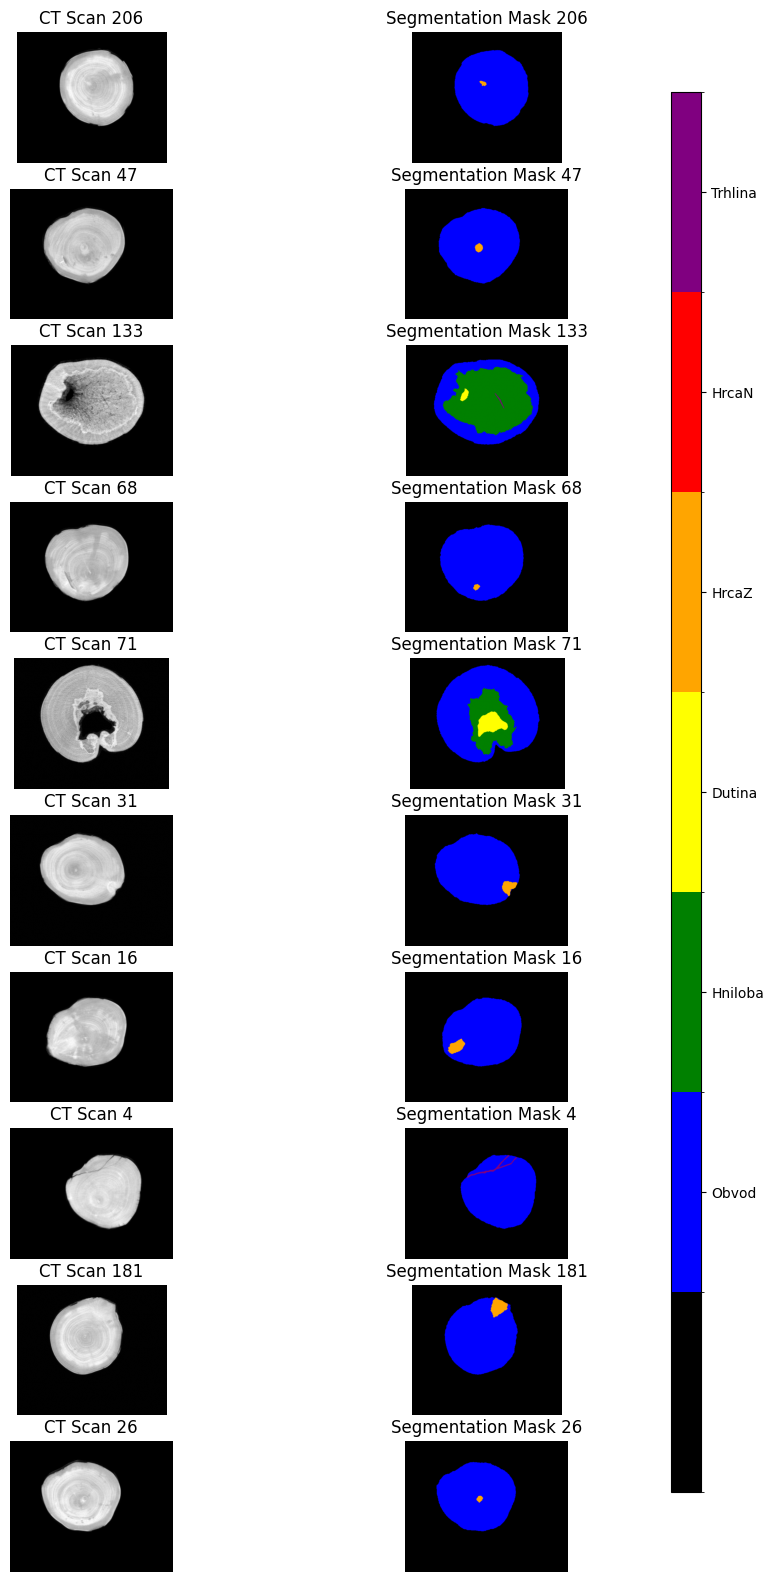

In [5]:
def load_image_and_mask(img_path, mask_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  # Load grayscale CT scan
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)  # Load labeled segmentation mask
    return img, mask

# Select random samples
num_samples = 10
random_indices = random.sample(range(len(filtered_image_paths)), num_samples)

fig, axes = plt.subplots(num_samples, 2, figsize=(10, 2 * num_samples))

for i, idx in enumerate(random_indices):
    img, mask = load_image_and_mask(filtered_image_paths[idx], filtered_mask_paths[idx])

    # Plot CT Scan
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f"CT Scan {idx}")
    axes[i, 0].axis('off')

    # Plot Segmentation Mask with colormap
    im = axes[i, 1].imshow(mask, cmap=cmap, norm=norm)
    axes[i, 1].set_title(f"Segmentation Mask {idx}")
    axes[i, 1].axis('off')

# Adjust layout to fit colorbar outside
plt.subplots_adjust(right=0.85)

# Create a new axis for the colorbar
cbar_ax = fig.add_axes([0.87, 0.15, 0.03, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_ticks(range(1, 7))
cbar.set_ticklabels([class_names[i] for i in range(1, 7)])

plt.show()

### Check all the unique labels
There is unexpected label 9. Needs further exploration.

In [6]:
all_labels = []
for mask_path in filtered_mask_paths:
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED).flatten()
    all_labels.extend(mask)

unique_labels = np.unique(all_labels)
print(f"Unique labels in masks: {unique_labels}")

Unique labels in masks: [0 1 2 3 4 5 6 9]


In [7]:
masks_with_label_9 = [mask_path for mask_path in filtered_mask_paths if 9 in np.unique(cv2.imread(mask_path, cv2.IMREAD_UNCHANGED))]

print(f"Total masks with label 9: {len(masks_with_label_9)}")
print("Example file paths:", masks_with_label_9)

Total masks with label 9: 2
Example file paths: ['./Dataset\\buk-out-5300\\buk-5300-113\\LabelingProject\\GroundTruthProject\\PixelLabelData\\Label_1_113_W974175300_2.png', './Dataset\\buk-out-5300\\buk-5300-164\\LabelingProject\\GroundTruthProject\\PixelLabelData\\Label_1_164_W974175300_2.png']


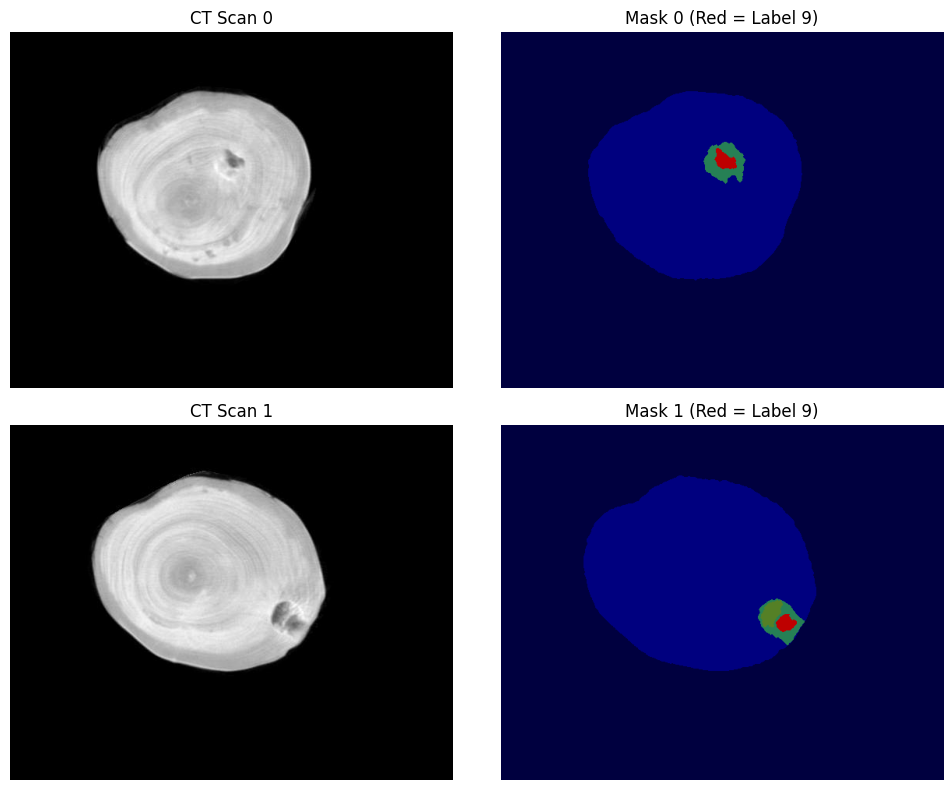

In [8]:
num_samples = len(masks_with_label_9)
fig, axes = plt.subplots(num_samples, 2, figsize=(10, 4 * num_samples))

for i, mask_path in enumerate(masks_with_label_9):
    img_path = filtered_image_paths[filtered_mask_paths.index(mask_path)]  # Match image to mask

    # Load image and mask
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)

    # Create red highlight for label 9
    mask_highlight = np.zeros((*mask.shape, 3), dtype=np.uint8)
    mask_highlight[mask == 9] = [255, 0, 0]

    # Plot CT scan
    axes[i, 0].imshow(img, cmap='gray')
    axes[i, 0].set_title(f"CT Scan {i}")
    axes[i, 0].axis('off')

    # Plot mask + overlay
    axes[i, 1].imshow(mask, cmap="jet")
    axes[i, 1].imshow(mask_highlight, alpha=0.5)
    axes[i, 1].set_title(f"Mask {i} (Red = Label 9)")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()


After consultation with domain expert the class 9 is class 3. It will be necessary to convert in preprocessing stage.

### Checking the class distribution of defect classes both pixel and slice representation context

In [9]:
def class_distribution(class_names):
    pixel_counts = Counter({key: 0 for key in class_names.keys()})
    slice_counts = Counter({key: 0 for key in class_names.keys()})
    
    for mask_path in filtered_mask_paths:
        mask = cv2.imread(mask_path, cv2.IMREAD_UNCHANGED)
        
        # Count pixels for each defect class
        unique, counts = np.unique(mask, return_counts=True)
        for u, c in zip(unique, counts):
            if u in class_names:  # Ignore classes 0 and 1
                pixel_counts[u] += c
        
        # Count slices where defects are present
        unique_labels = [u for u in unique if u in class_names]  # Filter valid defect classes
        for label in unique_labels:
            slice_counts[label] += 1
    
    classes = list(class_names.keys())
    pixel_values = [pixel_counts[c] for c in classes]
    slice_values = [slice_counts[c] for c in classes]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pixel-based distribution
    axes[0].bar(classes, pixel_values, tick_label=[class_names[c] for c in classes], color='skyblue')
    axes[0].set_xlabel("Defect Class")
    axes[0].set_ylabel("Pixel Count")
    axes[0].set_title("Defect Class Distribution (Pixel-Based)")
    axes[0].set_xticks(classes)
    axes[0].tick_params(axis='x', rotation=45)
    
    # Slice-based occurrence
    axes[1].bar(classes, slice_values, tick_label=[class_names[c] for c in classes], color='lightcoral')
    axes[1].set_xlabel("Defect Class")
    axes[1].set_ylabel("Number of Slices Containing Defect")
    axes[1].set_title("Defect Occurrence Per Slice")
    axes[1].set_xticks(classes)
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("Defect Pixel Counts:", pixel_counts)
    print("Defect Slice Occurrences:", slice_counts)

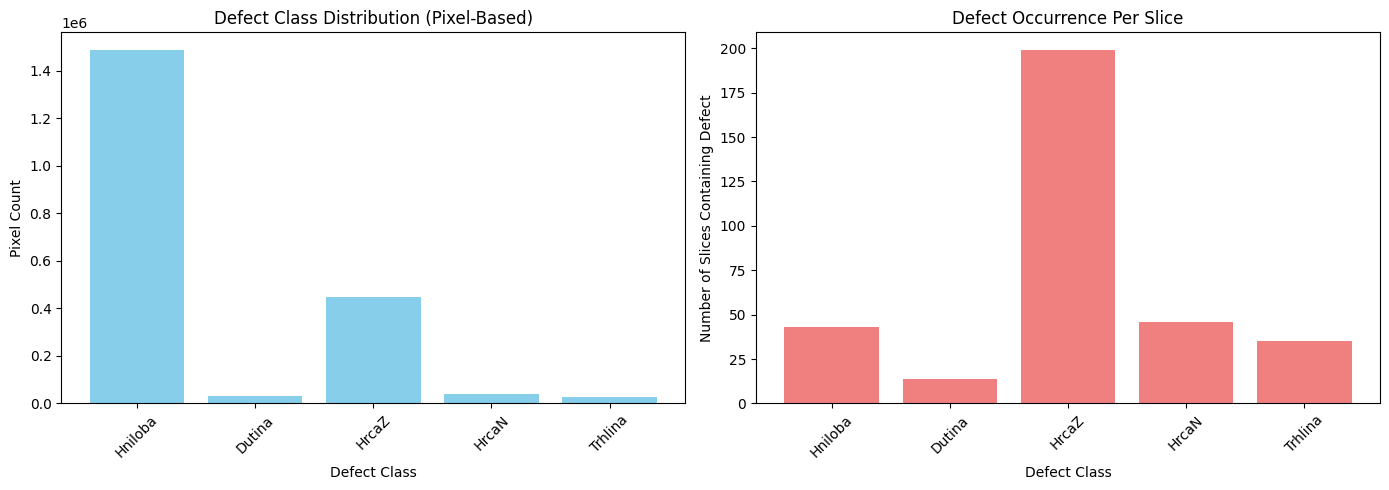

Defect Pixel Counts: Counter({2: 1486470, 4: 446295, 5: 41328, 3: 32340, 6: 28124})
Defect Slice Occurrences: Counter({4: 199, 5: 46, 2: 43, 6: 35, 3: 14})


In [10]:
class_names = {
    2: "Hniloba",
    3: "Dutina",
    4: "HrcaZ",
    5: "HrcaN",
    6: "Trhlina"
}

class_distribution(class_names)

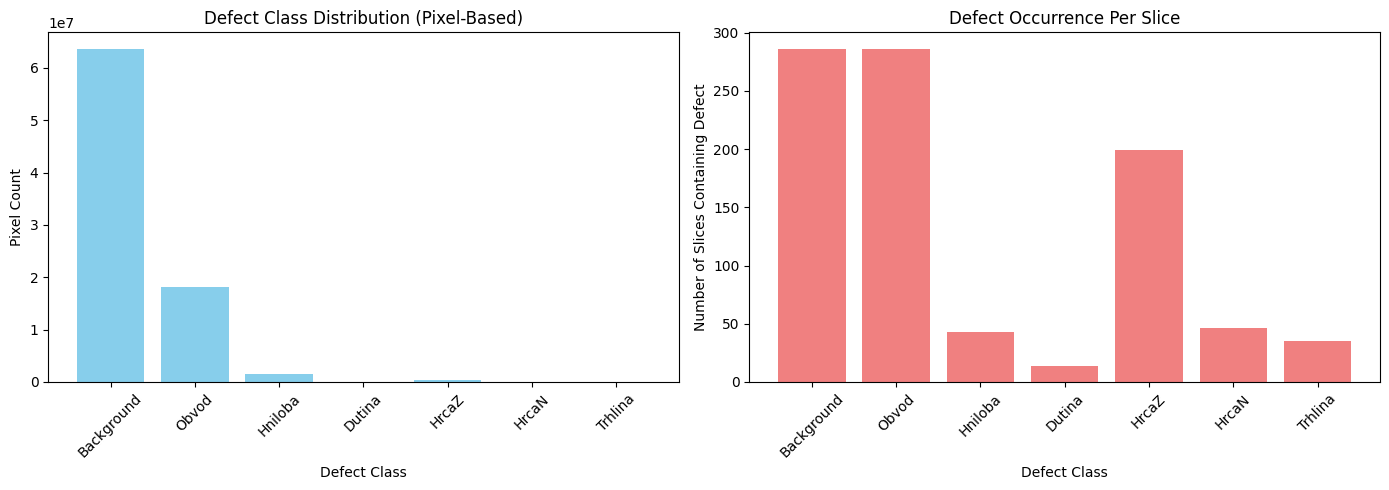

Defect Pixel Counts: Counter({0: 63594476, 1: 18078709, 2: 1486470, 4: 446295, 5: 41328, 3: 32340, 6: 28124})
Defect Slice Occurrences: Counter({0: 286, 1: 286, 4: 199, 5: 46, 2: 43, 6: 35, 3: 14})


In [11]:
class_names = {
    0: "Background",
    1: "Obvod",
    2: "Hniloba",
    3: "Dutina",
    4: "HrcaZ",
    5: "HrcaN",
    6: "Trhlina"
}

class_distribution(class_names)

"Hniloba" has the highest pixel count, which from visualization where the defect seem to always contain the highest area out of the defects seems right. In terms of occurence all of the classes seem to be evenly distibuted besides "HrcaZ". It is a healthy knot, in terms of actual occurence its okay, sometimes actually desired. The higher occurence is therefore expected. On the other hand the much higher occurence compared to "HrcaN", which represent unhealhy knots could potentially cause a problem in differentiating them.

### Checking defect sizes distribution

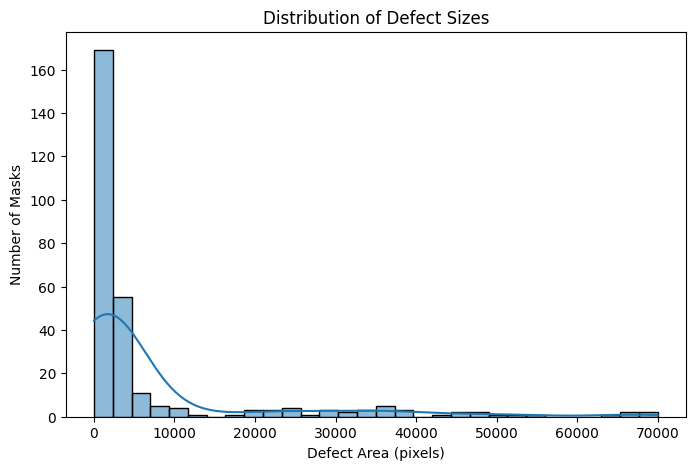

In [12]:
defect_sizes = [
    np.sum((cv2.imread(mask_path, cv2.IMREAD_UNCHANGED) > 1))  # Count pixels where label is 2-6
    for mask_path in mask_paths
]

plt.figure(figsize=(8, 5))
sns.histplot(defect_sizes, bins=30, kde=True)
plt.xlabel("Defect Area (pixels)")
plt.ylabel("Number of Masks")
plt.title("Distribution of Defect Sizes")
plt.show()


Majority of the defects are on the lower size. Most are around 5000 pixels.

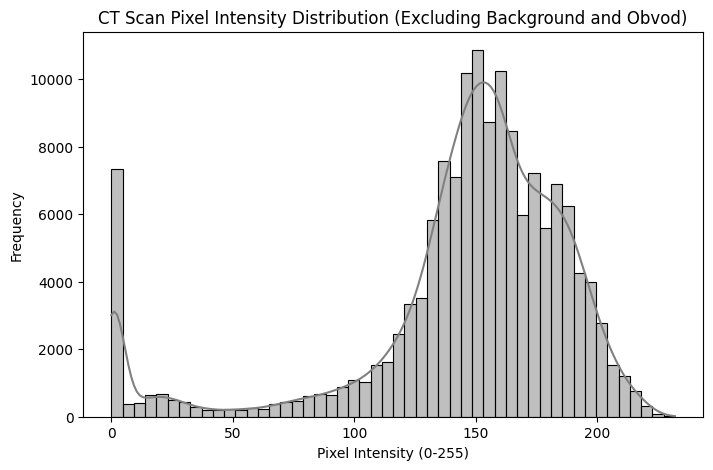

In [13]:
all_pixel_values = []

sample_size = 20
sample_indices = random.sample(range(len(filtered_image_paths)), sample_size)

for idx in sample_indices:
    img = cv2.imread(filtered_image_paths[idx], cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(filtered_mask_paths[idx], cv2.IMREAD_UNCHANGED)

    # Exclude background and obvod pixels (class 0 and 1)
    valid_pixels = img[mask > 1]  
    all_pixel_values.extend(valid_pixels.flatten())

plt.figure(figsize=(8, 5))
sns.histplot(all_pixel_values, bins=50, kde=True, color="gray")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.title("CT Scan Pixel Intensity Distribution (Excluding Background and Obvod)")
plt.show()

0 = completely black, 255 = completely white. 

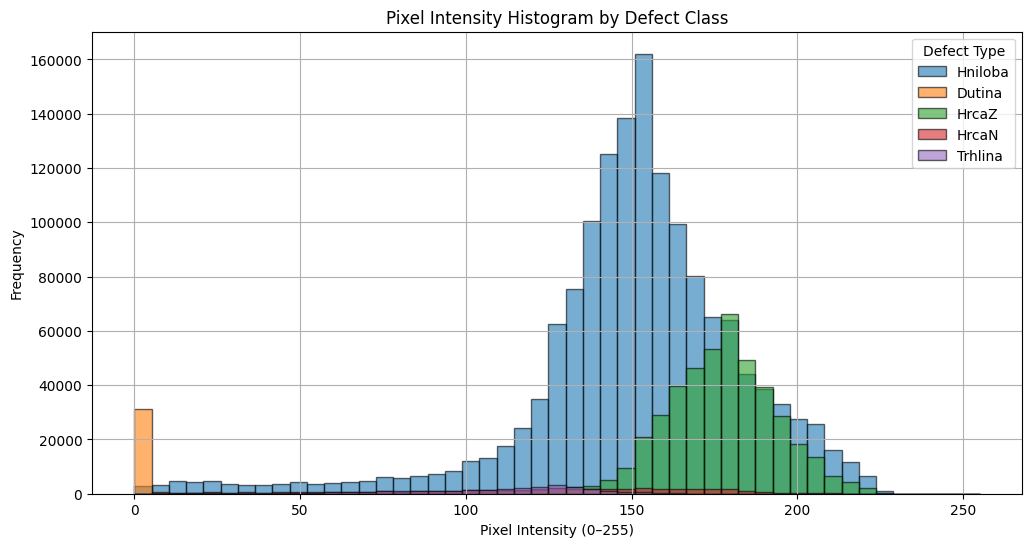

In [22]:
class_names = {
    2: "Hniloba",
    3: "Dutina",
    4: "HrcaZ",
    5: "HrcaN",
    6: "Trhlina"
}

all_pixel_values_by_class = {label: [] for label in class_names}

sample_size = 286
sample_indices = random.sample(range(len(filtered_image_paths)), sample_size)

for idx in sample_indices:
    img = cv2.imread(filtered_image_paths[idx], cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(filtered_mask_paths[idx], cv2.IMREAD_UNCHANGED)

    for label in class_names:
        valid_pixels = img[mask == label]
        all_pixel_values_by_class[label].extend(valid_pixels.flatten())

plt.figure(figsize=(12, 6))

bins = np.linspace(0, 255, 50)

for label, pixel_values in all_pixel_values_by_class.items():
    plt.hist(
        pixel_values,
        bins=bins,
        alpha=0.6,
        label=class_names[label],
        edgecolor='black'
    )

plt.xlabel("Pixel Intensity (0–255)")
plt.ylabel("Frequency")
plt.title("Pixel Intensity Histogram by Defect Class")
plt.legend(title="Defect Type")
plt.grid(True)
plt.show()

There's overlap between some classes like hniloba and trhlina, which could make classification harder if based on just the pixel intensity. Fortunatelly, the defect area for hniloba tends to be large and trhlina really narrow. Therefore, whenever deciding whether the defect is hniloba or other defect based on pixel intensity, the size of the defect can help determine which one is it.

In [15]:
image_shapes = [cv2.imread(img_path, cv2.IMREAD_GRAYSCALE).shape for img_path in filtered_image_paths]

# Count unique resolutions
res_counts = Counter(image_shapes)

for res, count in res_counts.items():
    print(f"Resolution {res}: {count} images")

Resolution (457, 569): 71 images
Resolution (529, 625): 25 images
Resolution (569, 673): 34 images
Resolution (513, 633): 35 images
Resolution (497, 569): 47 images
Resolution (465, 561): 74 images


Varied resolutions: either resize with some interpolation or crop. Since edgelines contain just background it should be ok to just crop every image.